<a href="https://colab.research.google.com/github/NatShed/MO_Attack/blob/main/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 3. Оптимизация, регуляризация и робастность нейросети

**Курс:** Машинное обучение. Безопасность ИИ-систем

**Формат:** индивидуально

**Среда:** Python, PyTorch

**По материалам Лекции 2.1 и Лекции 2.2**

## Цель работы
Экспериментально проверить, как выбор оптимизатора и методов регуляризации влияет на сходимость, переобучение, обобщение и чувствительность модели к возмущениям входа.

## Результаты обучения
После выполнения работы вы должны уметь:
- объяснять идею прямого прохода и backpropagation через цепное правило;
- различать SGD, Momentum и Adam с точки зрения траектории оптимизации и свойств найденного минимума;
- применять L2-регуляризацию, Dropout, BatchNorm и early stopping;
- оценивать train/test gap как признак переобучения;
- связывать переобучение и уязвимость модели к малым возмущениям входа.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.


## 0. Подготовка окружения

In [2]:
# TODO: импортируйте необходимые библиотеки
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## 1. Данные

**Задание:** загрузите датасет для классификации изображений.
Рекомендуется MNIST или Fashion-MNIST (через `torchvision.datasets`).


In [4]:
# TODO: загрузите датасет (например, torchvision.datasets.MNIST)
# TODO: создайте train/val/test DataLoader-ы

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# ToTensor() переводит картинку в тензор и масштабирует пиксели в [0, 1]
# Normalize() вычитает среднее и делит на std (стандартные значения для MNIST)
transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.1307,), (0.3081,))])

#Загружаем полный тренировочный и тестовый датасеты
train_dataset_full = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

#Разделяем тренировочный датасет на train и val (80% / 20%)
val_size = int(0.2 * len(train_dataset_full))
train_size = len(train_dataset_full) - val_size

train_dataset, val_dataset = random_split(train_dataset_full, [train_size, val_size], generator=torch.Generator().manual_seed(RANDOM_STATE))

#Создаём DataLoader-ы
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 5. Проверяем размеры
print(f"Train size: {len(train_dataset)}")
print(f"Val size:   {len(val_dataset)}")
print(f"Test size:  {len(test_dataset)}")
print("Размер изображения:", train_dataset[0][0].shape, "| число классов: 10")


100%|██████████| 9.91M/9.91M [00:00<00:00, 62.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.82MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 13.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.11MB/s]


Train size: 48000
Val size:   12000
Test size:  10000
Размер изображения: torch.Size([1, 28, 28]) | число классов: 10


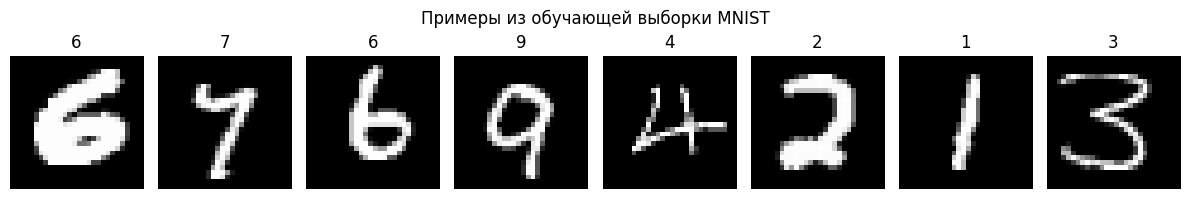

In [ ]:
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, idx in zip(axes, range(8)):
    img, lbl = train_dataset[idx]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(str(lbl))
    ax.axis("off")
plt.suptitle("Примеры из обучающей выборки MNIST")
plt.tight_layout()
plt.show()

## 2. Формализм прямого прохода и backpropagation

**Задание:** опишите (в markdown, формулами) прямой проход для вашей архитектуры и кратко распишите, как вычисляется ошибка слоя \( \delta^{(l)} \) через цепное правило.

**Вопрос для отчёта:** почему backpropagation имеет вычислительную сложность \(O(P)\) по числу параметров, а не \(O(2P)\), как при наивном численном дифференцировании?


**Прямой проход**
Рассмотрим сеть с L слоями. Для слоя l прямой проход задаётся следующими
уравнениями:
$$ z^{(l)} = W^{(l)}a^{(l-1)} + b^{(l)},    a^{(l)} = f(z^{(l)})$$

Здесь мы используем следующие обозначения:

$f$ – функция активации (ReLU,
sigmoid, tanh и др.)

$a^{(0)} = x $ – вход сети

$a^{(L)}$ – выход сети (предсказание)

$W^{(l)}$, $b^{(l)}$ – матрица весов и вектор смещений слоя l

Рассмотрим прямой проход конкретно для нашей архитектуры (классификация MNIST). На вход мы подаем картинку 28х28, т.е. 784 пикселя. Всего у нас будет три слоя: два скрытых и выходной слой. На первом скрытом слое: 256 нейронов (признаков). На втором – также 256. Выходной слой – слой с 10 нейронами, каждый из которых соотвествует цифре от 0 до 9.
В качестве функции активации (которая нужна, чтобы убрать линейность, чтобы сеть смогла выучить сложные зависимости) возьмем функцию ReLU(Rectified Linear Unit), которая выглядит следующим образом: $$ f(z) = max(0,z)$$  то есть это работает просто как маска: где вход был > 0, там градиент проходит, иначе обнуляется.

Распишем прямой проход для сети с тремя слоями.

Входной слой:
$a^{(0)} = x ∈ R^{784}$

Скрытый слой 1:
$$ z^{(1)} = W^{(1)}a^{(0)} + b^{(1)}$$
$$    a^{(1)} = f(z^{(1)}) = f ( W^{(1)}a^{(0)} + b^{(1)})$$

Скрытый слой 2:
$$ z^{(2)} = W^{(2)}a^{(1)} + b^{(2)}
= W^{(2)}f(z^{(1)}) + b^{(2)} = W^{(2)}f ( W^{(1)}a^{(0)} + b^{(1)}) + b^{(2)}$$

$$    a^{(2)} = f(z^{(2)}) = f ( W^{(2)}f ( W^{(1)}a^{(0)} + b^{(1)}) + b^{(2)})$$

Выходной слой (слой 3):
$$ z^{(3)} = W^{(3)}a^{(2)} + b^{(3)}
= W^{(3)}f ( W^{(2)}f ( W^{(1)}a^{(0)} + b^{(1)}) + b^{(2)}) + b^{(3)}$$

$$ a_c^{(L)} =  z^{(3)} $$

После выходного слоя нас ждет функция потерь, которая сравнивает предсказание с истинной меткой (для задачи классификации типично используется кросс-энтропия, которая измеряет расстояние между предсказанными вероятностями модели и реальными правильными ответами, это показывает нам, насколько сильно модель уверена в неправильном ответе).

$$L = -\sum_c y_c loga_c^{(L)}$$

$C$ – количество классов (у нас их 10)

$y_c$ – истинная метка, правильный ответ. Например, если правильный ответ — цифра «5», то $y_c$ = [0,0,0,0,0,1,0,0,0,0]. Единица стоит только на позиции правильного класса, остальные — нули.

$a_c^{(L)}$ – наше предсказание, а именнно предсказанная вероятность для класса $c$. Например, модель уверена на 95%, что это цифра 5, и на 5%, что это может быть 6. Тогда $a_c^{(L)}$ = [0,0,0,0,0,0.95,0.05,0,0,0].

Цель обучения – минимизировать $L$ через изменения весов и смещения.

Но чтобы модель обучалась мы используем алгоритм backpropogation (обратно распространение ошикби). При прямом проходе сеть, получая входные данные, выдает предсказание, происходит проверка ответа, при ошибке сеть должна понять, где именно она ошиблась, на каком шаге, и подкорректировать веса, где ошибка была наибольшей. Это обратное распространение ошибки основано на цепном правиле дифференцирования.

Введем ошибку слоя: $$\delta^{(l)} = ∂L/∂ z^{(l)} $$ (по факту это градиент потерь по логитам, а не по вероятностям)

На выходном слое ошибка будет:
$$δ^{(L)} = ∇_{a^{(L)}}L ⊙ f'(z^{(L)})$$

где — покомпонентное
произведение (Hadamard product).
Градиент потерь по активациям
умножается поэлементно на
производную функции активации.

Для комбинации Linear + Cross-Entropy (с Softmax внутри) это просто разница между предсказанными вероятностями и истинными метками:
$$δ^{(3)} = \frac{∂L}{∂z^{(3)}} = \frac{∂L}{∂a^{(3)}} * \frac{∂a^{(3)}}{∂z^{(3)}} = a^{(3)} - y_3$$

Цепное правило дифференцирования говорит нам, что чтобы найти влияение через цепочку, нужно перемножить влияние на каждом шаге.
$$\frac{∂Ошибка}{∂W_1}
= \frac{∂Ошибка}{∂Ответ} * \frac{∂Ответ}{∂Нейрон 3} * \frac{∂Нейрон 3}{∂Нейрон 2} * \frac{∂Нейрон 2}{∂W_1}$$

То есть мы берем ошибку следующего слоя и распостраняем ее назад через каждый слой, пропуская через транспонированную матрицу весов следующего слоя, умноженную на производную активации текущего слоя.
$$δ^{(l)} =((W^{(l+1)})^T δ^{(l+1)}) ⊙ f'(z^{(l)})$$

Так ошибка для первого слоя у нас будет выглядеть так:
$$δ^{(1)} =((W^{(2)})^T (((W^{(3)})^T δ^{(3)}) ⊙ f'(z^{(2)}))) ⊙ f'(z^{(1)})$$

Теперь нам нужно узнать градиенты по весам и смещениям, чтобы понять, в какую сторону и насколько сильно нужно изменить эти параметры, чтобы уменьшить ошибку. Градиенты получаются напрямую из вычисленных ошибок без дополнительных вычислений:

$$\frac{∂L}{∂W^{(l)}} = δ^{(a)}(a^{(l-1)})^T$$
$$ \frac{∂L}{∂b^{(l)}} = δ^{(l)}$$

Если градиент положительный - увелечение веса увеличит ошибку, значит, чтобы ее уменьшить, нужно уменьшить и вес. Аналогичнло, если градиент отрицательный, увелечение вес уменьшит ошибку.

У такого вычисления есть ключевое преимущество: алгоритм backprop за счет повторного использования промежуточных величин ошибки слоя. Каждая величина вычисляется ровно один раз и используется при вычислении градиентов для всех нижележащих слоев. При наивном численном дифференцировании нам бы пришлос делать для каждого из P параметров два прямых прохода с (туда-обратно с
$w+ε$ и $w-ε$). Это $O(P^2)$, что невозможно для сетей с большим количеством параметров. Наш же алгоритм имеет линейную сложность $O(P)$

## 3. Базовая архитектура сети

In [6]:
# TODO: определите класс простого MLP (2-3 полносвязных слоя)
# Параметризуйте модель так, чтобы можно было легко включать/выключать dropout и batchnorm

class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, use_dropout=False, use_batchnorm=False, dropout_p=0.5):
    #input_dim — размер входного вектора (для MNIST — 784).
    #hidden_dim — число нейронов в скрытых слоях (256).
    #num_classes — число классов на выходе (для MNIST — 10).
    #use_dropout, use_batchnorm — флаги-переключатели регуляризации.
    #dropout_p — вероятность отключения нейрона (по умолчанию 0.5).
        super().__init__()
        self.use_dropout = use_dropout
        self.use_batchnorm = use_batchnorm

        # Первый слой. Из 784 пикселя извелкается 256 прищнаков
        self.fc1 = nn.Linear(input_dim, hidden_dim)  # 784 -> 256, Вычисляет z = Wx + b.
        self.bn1 = nn.BatchNorm1d(hidden_dim) if use_batchnorm else None #нормализация выходов каждого слоя внутри батча
        self.drop1 = nn.Dropout(dropout_p) if use_dropout else None #выключаем половину нейронов, чтобы все нейроны учились и сеть не полагалась на те же самые

        # Второй слой. Продолжаем работать с этими 256 признаками, но создаем еще 256 новыз, более абстрактных
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)  # 256 -> 256. модель учит более сложные комбинации
        self.bn2 = nn.BatchNorm1d(hidden_dim) if use_batchnorm else None
        self.drop2 = nn.Dropout(dropout_p) if use_dropout else None

        # Выход. Выходной слой сжимает 256 до 10 (по числу классов)
        self.fc3 = nn.Linear(hidden_dim, num_classes)  # 256 -> 10

        self.act = nn.ReLU()

    def forward(self, x):
          '''
      проверяет размерность тензора x — то есть сколько у него осей
      (измерений).
      Если размерность больше 2, значит, данные пришли
      в «многомерном» виде (например, картинка), и их нужно развернуть
      в плоский вектор перед подачей в полносвязный слой.
      '''
          # 1. Разворачиваем картинку 28x28 в вектор 784
          if x.dim() > 2:
            x = x.view(x.size(0), -1)
            #x.size(0) — размер батча
            #-1 — «автоматически посчитать остальное» (1×28×28 = 784).

          # 2. Блок 1: Linear -> BatchNorm -> ReLU -> Dropout
          x = self.fc1(x)
          if self.use_batchnorm:
            x = self.bn1(x)
          x = self.act(x)
          if self.use_dropout:
            x = self.drop1(x)

          # 3. Блок 2: то же самое
          x = self.fc2(x)
          if self.use_batchnorm:
            x = self.bn2(x)
          x = self.act(x)
          if self.use_dropout:
            x = self.drop2(x)
            # 4. Выходной слой (без активации)
          x = self.fc3(x)
          return x

In [7]:
# TODO: напишите универсальные функции train_epoch(model, loader, optimizer, criterion, device)
# и evaluate(model, loader, criterion, device), возвращающие loss и accuracy

def train_epoch(model, loader, optimizer, criterion, device):
    """
    Обучает модель одну эпоху.

    Возвращает:
        avg_loss (float): средний loss по всем батчам
        accuracy (float): доля правильных предсказаний (0..1)
    """
    model.train() # Включаем режим обучения (Dropout/BatchNorm активны)
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        # 1. Переносим данные на устройство (GPU/CPU)
        images = images.to(device) # Размер текущего батча
        labels = labels.to(device) # количество примеров в батче

        # 2. Обнуляем старые градиенты
        optimizer.zero_grad()

        # 3. Прямой проход
        logits = model(images)

        # 4. Считаем Loss
        loss = criterion(logits, labels)

        # 5. Обратный проход (backpropagation)
        loss.backward()

        # 6. Обновляем веса
        optimizer.step()

        # 7. Накапливаем статистику
        running_loss += loss.item() * images.size(0)  # сумма loss по всем примерам
        preds = logits.argmax(dim=1) # индекс максимального значения логита в доль оси классов
        correct += (preds == labels).sum().item() # количество правельных предсказаний
        total += labels.size(0) # общее число примеров, прошедших через модель за эпоху.

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

def evaluate(model, loader, criterion, device):
    """
    Оценивает модель на валидации/тесте без обновления весов.

    Возвращает:
        avg_loss (float): средний loss
        accuracy (float): доля правильных предсказаний
    """
    model.eval()  # Отключаем Dropout, все нейроны активны, BatchNorm использует running stats
    # во время обучения BatchNorm считает среднее и дисперсию по каждому батчу отдельно,
    # но параллельно ведёт «бегущую» (running) память об этих значениях, чтобы потом использовать её на тесте.
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # Отключаем вычисление градиентов (экономия памяти и времени)
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            running_loss += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

## 4. Серия A. Сравнение оптимизаторов

**Задание:** обучите одну и ту же архитектуру (без дополнительной регуляризации) со следующими оптимизаторами:
- SGD;
- SGD + Momentum (momentum=0.9);
- Adam.

Для каждого варианта зафиксируйте одинаковое число эпох и одинаковый learning rate (или обоснуйте отличие).


In [9]:
# --- Гиперпараметры (одинаковые для всех оптимизаторов) ---
EPOCHS = 15
LR = 0.01 # размер шага
HIDDEN_DIM = 256
DROPOUT_P = 0.5
USE_DROPOUT = False       # без регуляризации
USE_BATCHNORM = False     # без BatchNorm

criterion = nn.CrossEntropyLoss()

In [ ]:
# TODO: обучите модель с оптимизатором SGD
# Сохраните историю train/test loss и accuracy по эпохам
print("1. Стохастический градиентный спуск – SGD")
print("=" * 60)

torch.manual_seed(RANDOM_STATE)  # фиксируем инициализацию весов

model_sgd = SimpleMLP(
    input_dim=784, hidden_dim=HIDDEN_DIM, num_classes=10,
    use_dropout=USE_DROPOUT, use_batchnorm=USE_BATCHNORM
).to(device)

optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=LR)

# Словарь для истории обучения
history_sgd = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

# --- Цикл обучения ---
for epoch in range(EPOCHS):
    # Одна эпоха обучения
    train_loss, train_acc = train_epoch(
        model_sgd, train_loader, optimizer_sgd, criterion, device
    )
    # Оценка на валидации
    test_loss, test_acc = evaluate(
        model_sgd, val_loader, criterion, device
    )

    # Сохраняем метрики
    history_sgd["train_loss"].append(train_loss)
    history_sgd["test_loss"].append(test_loss)
    history_sgd["train_acc"].append(train_acc)
    history_sgd["test_acc"].append(test_acc)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

1. Стохастический градиентный спуск – SGD
Epoch  1/15 | Train Loss: 0.8601, Acc: 0.7993 | Test Loss: 0.3834, Acc: 0.8892
Epoch  2/15 | Train Loss: 0.3209, Acc: 0.9082 | Test Loss: 0.3024, Acc: 0.9121
Epoch  3/15 | Train Loss: 0.2634, Acc: 0.9240 | Test Loss: 0.2684, Acc: 0.9215
Epoch  4/15 | Train Loss: 0.2278, Acc: 0.9343 | Test Loss: 0.2344, Acc: 0.9313
Epoch  5/15 | Train Loss: 0.2006, Acc: 0.9425 | Test Loss: 0.2114, Acc: 0.9388
Epoch  6/15 | Train Loss: 0.1783, Acc: 0.9495 | Test Loss: 0.1942, Acc: 0.9442
Epoch  7/15 | Train Loss: 0.1600, Acc: 0.9544 | Test Loss: 0.1824, Acc: 0.9467
Epoch  8/15 | Train Loss: 0.1449, Acc: 0.9591 | Test Loss: 0.1676, Acc: 0.9524
Epoch  9/15 | Train Loss: 0.1320, Acc: 0.9625 | Test Loss: 0.1575, Acc: 0.9550
Epoch 10/15 | Train Loss: 0.1206, Acc: 0.9658 | Test Loss: 0.1455, Acc: 0.9576
Epoch 11/15 | Train Loss: 0.1109, Acc: 0.9686 | Test Loss: 0.1390, Acc: 0.9592
Epoch 12/15 | Train Loss: 0.1026, Acc: 0.9710 | Test Loss: 0.1328, Acc: 0.9614
Epoch 13/1

In [ ]:
# TODO: обучите модель с оптимизатором SGD + Momentum
# Сохраните историю train/test loss и accuracy по эпохам
print("SGD + Momentum (импульс) (momentum=0.9)")
# контролируем энерцию - насколько сильно учитываются прошлые градиенты
# Новый градиент входит с весо 10%
# Старая накопленная энерция входит с весом 90%
print("=" * 60)

torch.manual_seed(RANDOM_STATE)   # фиксируем инициализацию весов — как у SGD и Adam

# Создаём модель той же архитектуры (без Dropout и BatchNorm)
model_sgd_momentum = SimpleMLP(
    input_dim=784,
    hidden_dim=HIDDEN_DIM,
    num_classes=10,
    use_dropout=USE_DROPOUT,
    use_batchnorm=USE_BATCHNORM
).to(device)

# Оптимизатор SGD с импульсом
optimizer_sgd_momentum = optim.SGD(
    model_sgd_momentum.parameters(),
    lr=LR,             # тот же learning rate, что и у SGD
    momentum=0.9       # ключевой параметр — импульс
)

# Словарь для истории обучения
history_sgd_momentum = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

# --- Цикл обучения ---
for epoch in range(EPOCHS):
    # Одна эпоха обучения
    train_loss, train_acc = train_epoch(
        model_sgd_momentum, train_loader, optimizer_sgd_momentum, criterion, device
    )
    # Оценка на валидации
    test_loss, test_acc = evaluate(
        model_sgd_momentum, val_loader, criterion, device
    )

    # Сохраняем метрики
    history_sgd_momentum["train_loss"].append(train_loss)
    history_sgd_momentum["test_loss"].append(test_loss)
    history_sgd_momentum["train_acc"].append(train_acc)
    history_sgd_momentum["test_acc"].append(test_acc)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

SGD + Momentum (импульс) (momentum=0.9)
Epoch  1/15 | Train Loss: 0.3381, Acc: 0.9014 | Test Loss: 0.1620, Acc: 0.9500
Epoch  2/15 | Train Loss: 0.1158, Acc: 0.9652 | Test Loss: 0.1145, Acc: 0.9655
Epoch  3/15 | Train Loss: 0.0756, Acc: 0.9765 | Test Loss: 0.0916, Acc: 0.9717
Epoch  4/15 | Train Loss: 0.0525, Acc: 0.9837 | Test Loss: 0.0889, Acc: 0.9737
Epoch  5/15 | Train Loss: 0.0396, Acc: 0.9878 | Test Loss: 0.0825, Acc: 0.9754
Epoch  6/15 | Train Loss: 0.0294, Acc: 0.9911 | Test Loss: 0.0820, Acc: 0.9752
Epoch  7/15 | Train Loss: 0.0208, Acc: 0.9939 | Test Loss: 0.0807, Acc: 0.9760
Epoch  8/15 | Train Loss: 0.0149, Acc: 0.9961 | Test Loss: 0.0839, Acc: 0.9755
Epoch  9/15 | Train Loss: 0.0112, Acc: 0.9969 | Test Loss: 0.0794, Acc: 0.9772
Epoch 10/15 | Train Loss: 0.0063, Acc: 0.9989 | Test Loss: 0.0745, Acc: 0.9792
Epoch 11/15 | Train Loss: 0.0037, Acc: 0.9995 | Test Loss: 0.0775, Acc: 0.9788
Epoch 12/15 | Train Loss: 0.0022, Acc: 0.9999 | Test Loss: 0.0756, Acc: 0.9790
Epoch 13/15 

In [ ]:
# TODO: обучите модель с оптимизатором Adam
# комбинирует адаптивные оценки первого и второго момента градиента
print("Adam (Adaptive Moment Estimation)")
print("=" * 60)

torch.manual_seed(RANDOM_STATE)   # та же инициализация весов, что у SGD и SGD+Momentum

# Та же архитектура: SimpleMLP, hidden_dim=256, без Dropout и BatchNorm
model_adam = SimpleMLP(
    input_dim=784,
    hidden_dim=HIDDEN_DIM,
    num_classes=10,
    use_dropout=USE_DROPOUT,
    use_batchnorm=USE_BATCHNORM
).to(device)

# Оптимизатор Adam
optimizer_adam = optim.Adam(
    model_adam.parameters(),
    lr=0.001 )
    # Если мы поставим тот LR, то адам будет делать гораздо более крупные шаги
    # это приведет к нестабильно и проскоку хороших точек
"""
Adam с LR=0.01 обгонял всех на первых эпохах,
но к 8–10 эпохе Test Loss начал расти, Accuracy колебалась.

Причина: Adam делал слишком большие шаги,
модель «мечется» вблизи минимума и не может стабилизироваться.
"""
# Словарь для истории обучения
history_adam = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

# --- Цикл обучения ---
for epoch in range(EPOCHS):
    # Одна эпоха обучения
    train_loss, train_acc = train_epoch(
        model_adam, train_loader, optimizer_adam, criterion, device
    )
    # Оценка на валидации
    test_loss, test_acc = evaluate(
        model_adam, val_loader, criterion, device
    )

    # Сохраняем метрики
    history_adam["train_loss"].append(train_loss)
    history_adam["test_loss"].append(test_loss)
    history_adam["train_acc"].append(train_acc)
    history_adam["test_acc"].append(test_acc)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")


Adam (Adaptive Moment Estimation)
Epoch  1/15 | Train Loss: 0.2405, Acc: 0.9270 | Test Loss: 0.1425, Acc: 0.9549
Epoch  2/15 | Train Loss: 0.0994, Acc: 0.9687 | Test Loss: 0.1129, Acc: 0.9653
Epoch  3/15 | Train Loss: 0.0688, Acc: 0.9783 | Test Loss: 0.0861, Acc: 0.9714
Epoch  4/15 | Train Loss: 0.0491, Acc: 0.9846 | Test Loss: 0.0954, Acc: 0.9742
Epoch  5/15 | Train Loss: 0.0393, Acc: 0.9863 | Test Loss: 0.1050, Acc: 0.9717
Epoch  6/15 | Train Loss: 0.0361, Acc: 0.9881 | Test Loss: 0.1037, Acc: 0.9713
Epoch  7/15 | Train Loss: 0.0268, Acc: 0.9905 | Test Loss: 0.1005, Acc: 0.9737
Epoch  8/15 | Train Loss: 0.0260, Acc: 0.9912 | Test Loss: 0.1063, Acc: 0.9764
Epoch  9/15 | Train Loss: 0.0228, Acc: 0.9925 | Test Loss: 0.1124, Acc: 0.9752
Epoch 10/15 | Train Loss: 0.0224, Acc: 0.9928 | Test Loss: 0.1191, Acc: 0.9735
Epoch 11/15 | Train Loss: 0.0185, Acc: 0.9941 | Test Loss: 0.1117, Acc: 0.9772
Epoch 12/15 | Train Loss: 0.0182, Acc: 0.9943 | Test Loss: 0.1090, Acc: 0.9772
Epoch 13/15 | Trai

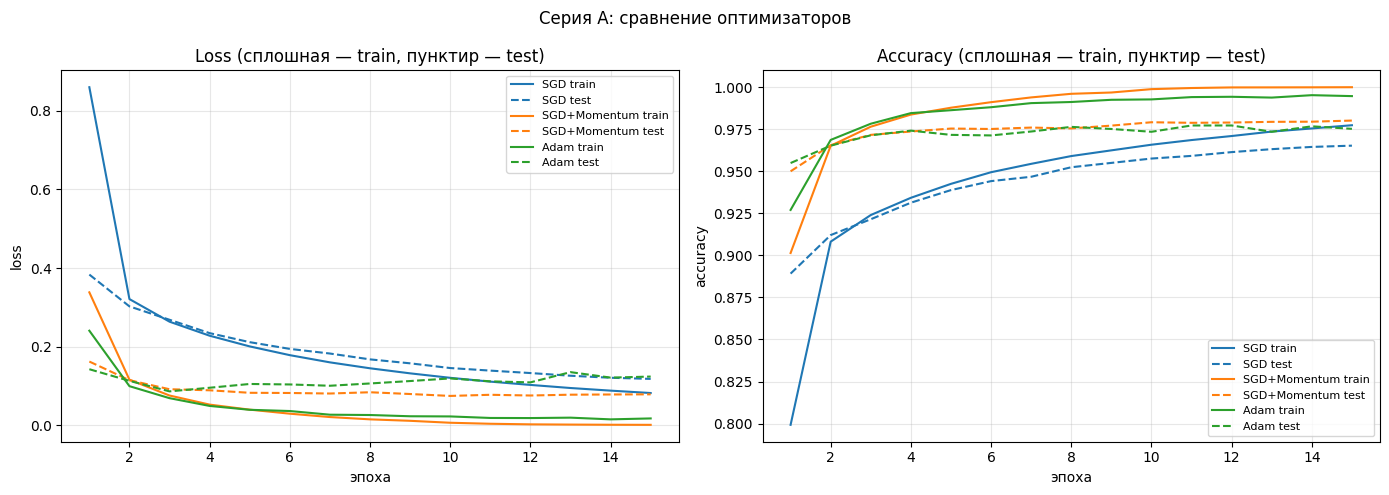

In [ ]:
# TODO: постройте графики train/test loss и train/test accuracy для всех трёх оптимизаторов
# Используйте единый график с несколькими линиями для удобного сравнения
histories_A = {
    "SGD": history_sgd,
    "SGD+Momentum": history_sgd_momentum,
    "Adam": history_adam,
}
colors = {"SGD": "tab:blue", "SGD+Momentum": "tab:orange", "Adam": "tab:green"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, h in histories_A.items():
    ep = range(1, len(h["train_loss"]) + 1)
    axes[0].plot(ep, h["train_loss"], color=colors[name], label=f"{name} train")
    axes[0].plot(ep, h["test_loss"],  color=colors[name], ls="--", label=f"{name} test")
    axes[1].plot(ep, h["train_acc"],  color=colors[name], label=f"{name} train")
    axes[1].plot(ep, h["test_acc"],   color=colors[name], ls="--", label=f"{name} test")

axes[0].set_xlabel("эпоха"); axes[0].set_ylabel("loss"); axes[0].set_title("Loss (сплошная — train, пунктир — test)")
axes[1].set_xlabel("эпоха"); axes[1].set_ylabel("accuracy"); axes[1].set_title("Accuracy (сплошная — train, пунктир — test)")
for ax in axes:
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.suptitle("Серия A: сравнение оптимизаторов")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
rows = []
for name, h in histories_A.items():
    # эпоха, на которой train accuracy впервые превысила 95% — грубая мера скорости сходимости
    ep95 = next((i + 1 for i, a in enumerate(h["train_acc"]) if a >= 0.96), None)
    rows.append({
        "optimizer": name,
        "train_loss": round(h["train_loss"][-1], 4),
        "test_loss": round(h["test_loss"][-1], 4),
        "train_acc": round(h["train_acc"][-1], 4),
        "test_acc": round(h["test_acc"][-1], 4),
        "gap": round(h["train_acc"][-1] - h["test_acc"][-1], 4),
        "gap_loss": round(h["test_loss"][-1] - h["train_loss"][-1], 4),
        "эпоха до train_acc>=95%": ep95,
    })
table_A = pd.DataFrame(rows)
table_A

,optimizer,train_loss,test_loss,train_acc,test_acc,gap,gap_loss,эпоха до train_acc>=95%
0,SGD,0.0819,0.1179,0.9774,0.9653,0.0121,0.0360,9
1,SGD+Momentum,0.0010,0.0786,1.0000,0.9802,0.0198,0.0776,2
2,Adam,0.0173,0.1238,0.9947,0.9752,0.0195,0.1065,2


**Вопрос для отчёта:** какой оптимизатор сходится быстрее? У какого варианта наибольший train/test gap? Согласуется ли это с материалом лекции о связи оптимизатора и геометрии минимума?

Adam и SGD + Momentum сходятся примерно одинаково быстро, уже к 3 эпохе у них Test Acc ≈ 97% (к 5 эпохе SGD + Momentum обогнал Adam), тогда как SGD сильно отстает: ему нужно 12+ эпох для такого уровня, он недообучен, 15 эпох ему не хватает.  

Разрыв между тренировочной и тестовой ошибкой наибольший у Adam, что говорит о его переобучении. Если мы посмотрим на его Test Loss, мы увидим, что оно прыгает вверх-вниз на протяжении всего обучения –  Adam нашел острый минимум. При этом Train Loss падает монотонно, модель запомнила тренировочные данны, но не выучила обобщаемые закономерности. О чем и было сказано в лекции.

Сравнивая с SGD+Momentum, мы можем заметить, что Test Loss у нее монотонно падает почти до конца, без прыжков, да, самый минимум у нас на 10 эпохе - 0,0745, на 15 эпохе вырос до 0,0786, разница между - всего 0,004, это в пределах шума. Так что можно сказать, что модель нашла плоский минимум и в нем зафиксировалась. Train Loss 0 и Train Acc 1 в данном случае не означают переобучение, просто модель очень хорошо подогналась под тренировочные данные. Модель стабильна.

Посмотрим на разницу между тестовой и тренировочной точностями. Наибольший Gap у SGD+Momentum (0.0198), затем Adam (0.0195), тут они тоже идут почти вровень, наименьший — у чистого SGD (0.0121). При этом Test Acc у Adam колеблется вокруг 97.5%, он не может закрепиться. Momentum растёт до 98.02%. Momentum медленнее разгонялся, но стабильно рост и держится на одном уровне.

Все это подтверждает лекцию: выбор оптимизатора определяет геометрию найденного минимума, а она — обобщение и устойчивость. Adam тяготеет к острым минимумам, плоские же минимумы харакетрны для для SGD с малыми батчами, шум SGD служит неявной регулязацией. Острый минимум проявляется в нестабильности Test Loss и Test Acc и делает модель уязвимой к adcersarial-атакам. Плоский минимум виден в монотонном падении Test Loss и стабильном росте Test Acc, устойчив к возмущениям входа и хорошо обобщает на тестовых данныъ.

Таким образом, для данной задачи лучшая модель - SGD + Momentum, который дает лучшее качество с хорошей динамикой за счет импульса.

## 5. Серия B. Сравнение методов регуляризации

**Задание:** для оптимизатора, выбранного по результатам серии A (или заданного преподавателем), обучите варианты модели:
- без регуляризации (baseline);
- с L2-регуляризацией (weight_decay (сжатие весов) в оптимизаторе);
- с Dropout;
- с BatchNorm;
- (опционально) с early stopping по валидационному loss.


In [32]:
# TODO: baseline без регуляризации
print("B1. Baseline (без регуляризации)")
print("=" * 60)

torch.manual_seed(RANDOM_STATE)

model_baseline = SimpleMLP(
    input_dim=784, hidden_dim=HIDDEN_DIM, num_classes=10,
    use_dropout=False,
    use_batchnorm=False
).to(device)

optimizer_baseline = optim.SGD(
    model_baseline.parameters(), lr=LR, momentum=0.9
)

history_baseline = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(
        model_baseline, train_loader, optimizer_baseline, criterion, device
    )
    test_loss, test_acc = evaluate(
        model_baseline, val_loader, criterion, device
    )
    history_baseline["train_loss"].append(train_loss)
    history_baseline["test_loss"].append(test_loss)
    history_baseline["train_acc"].append(train_acc)
    history_baseline["test_acc"].append(test_acc)
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")
print("=" * 60)
print(f"\n[Baseline] Финальный Test Accuracy: {history_baseline['test_acc'][-1]:.4f}")
print(f"[Baseline] Train/Test Gap (Acc): {history_baseline['train_acc'][-1] - history_baseline['test_acc'][-1]:.4f}")
print(f"[Baseline] Train/Test Gap (Loss): {history_baseline['test_loss'][-1] - history_baseline['train_loss'][-1]:.4f}")


B1. Baseline (без регуляризации)
Epoch  1/15 | Train Loss: 0.3381, Acc: 0.9014 | Test Loss: 0.1620, Acc: 0.9500
Epoch  2/15 | Train Loss: 0.1158, Acc: 0.9652 | Test Loss: 0.1145, Acc: 0.9655
Epoch  3/15 | Train Loss: 0.0756, Acc: 0.9765 | Test Loss: 0.0916, Acc: 0.9717
Epoch  4/15 | Train Loss: 0.0525, Acc: 0.9837 | Test Loss: 0.0889, Acc: 0.9737
Epoch  5/15 | Train Loss: 0.0396, Acc: 0.9878 | Test Loss: 0.0825, Acc: 0.9754
Epoch  6/15 | Train Loss: 0.0294, Acc: 0.9911 | Test Loss: 0.0820, Acc: 0.9752
Epoch  7/15 | Train Loss: 0.0208, Acc: 0.9939 | Test Loss: 0.0807, Acc: 0.9760
Epoch  8/15 | Train Loss: 0.0149, Acc: 0.9961 | Test Loss: 0.0839, Acc: 0.9755
Epoch  9/15 | Train Loss: 0.0112, Acc: 0.9969 | Test Loss: 0.0794, Acc: 0.9772
Epoch 10/15 | Train Loss: 0.0063, Acc: 0.9989 | Test Loss: 0.0745, Acc: 0.9792
Epoch 11/15 | Train Loss: 0.0037, Acc: 0.9995 | Test Loss: 0.0775, Acc: 0.9788
Epoch 12/15 | Train Loss: 0.0022, Acc: 0.9999 | Test Loss: 0.0756, Acc: 0.9790
Epoch 13/15 | Train

In [33]:
# TODO: L2-регуляризация (weight_decay)
print("B2. L2-регуляризация (weight_decay=1e-3)")
print("=" * 60)

torch.manual_seed(RANDOM_STATE)

model_l2 = SimpleMLP(
    input_dim=784, hidden_dim=HIDDEN_DIM, num_classes=10,
    use_dropout=False,
    use_batchnorm=False
).to(device)

# weight_decay — это и есть λ в формуле L2-регуляризации
optimizer_l2 = optim.SGD(
    model_l2.parameters(), lr=LR, momentum=0.9,
    weight_decay=1e-3          # λ = 0.001
)

history_l2 = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(
        model_l2, train_loader, optimizer_l2, criterion, device
    )
    test_loss, test_acc = evaluate(
        model_l2, val_loader, criterion, device
    )
    history_l2["train_loss"].append(train_loss)
    history_l2["test_loss"].append(test_loss)
    history_l2["train_acc"].append(train_acc)
    history_l2["test_acc"].append(test_acc)
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")
print("=" * 60)
print(f"\n[L2] Финальный Test Accuracy: {history_l2['test_acc'][-1]:.4f}")
print(f"[L2] Train/Test Gap (Acc): {history_l2['train_acc'][-1] - history_l2['test_acc'][-1]:.4f}")
print(f"[L2] Train/Test Gap (Loss): {history_l2['test_loss'][-1] - history_l2['train_loss'][-1]:.4f}")

B2. L2-регуляризация (weight_decay=1e-3)
Epoch  1/15 | Train Loss: 0.3411, Acc: 0.9005 | Test Loss: 0.1662, Acc: 0.9494
Epoch  2/15 | Train Loss: 0.1217, Acc: 0.9638 | Test Loss: 0.1219, Acc: 0.9641
Epoch  3/15 | Train Loss: 0.0830, Acc: 0.9748 | Test Loss: 0.0969, Acc: 0.9707
Epoch  4/15 | Train Loss: 0.0617, Acc: 0.9814 | Test Loss: 0.0903, Acc: 0.9728
Epoch  5/15 | Train Loss: 0.0500, Acc: 0.9859 | Test Loss: 0.0830, Acc: 0.9755
Epoch  6/15 | Train Loss: 0.0419, Acc: 0.9880 | Test Loss: 0.0810, Acc: 0.9748
Epoch  7/15 | Train Loss: 0.0344, Acc: 0.9910 | Test Loss: 0.0836, Acc: 0.9744
Epoch  8/15 | Train Loss: 0.0298, Acc: 0.9924 | Test Loss: 0.0820, Acc: 0.9743
Epoch  9/15 | Train Loss: 0.0268, Acc: 0.9932 | Test Loss: 0.0797, Acc: 0.9744
Epoch 10/15 | Train Loss: 0.0241, Acc: 0.9942 | Test Loss: 0.0678, Acc: 0.9784
Epoch 11/15 | Train Loss: 0.0222, Acc: 0.9944 | Test Loss: 0.0679, Acc: 0.9783
Epoch 12/15 | Train Loss: 0.0206, Acc: 0.9955 | Test Loss: 0.0701, Acc: 0.9771
Epoch 13/15

In [34]:
# TODO: Dropout
print("B3. Dropout (p=0.5)")
print("=" * 60)

torch.manual_seed(RANDOM_STATE)

model_dropout = SimpleMLP(
    input_dim=784, hidden_dim=HIDDEN_DIM, num_classes=10,
    use_dropout=True,
    dropout_p=0.5,
    use_batchnorm=False
).to(device)

optimizer_dropout = optim.SGD(
    model_dropout.parameters(), lr=LR, momentum=0.9
)

history_dropout = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(
        model_dropout, train_loader, optimizer_dropout, criterion, device
    )
    test_loss, test_acc = evaluate(
        model_dropout, val_loader, criterion, device
    )
    history_dropout["train_loss"].append(train_loss)
    history_dropout["test_loss"].append(test_loss)
    history_dropout["train_acc"].append(train_acc)
    history_dropout["test_acc"].append(test_acc)
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")
print("=" * 60)
print(f"\n[Dropout] Финальный Test Accuracy: {history_dropout['test_acc'][-1]:.4f}")
print(f"[Dropout] Train/Test Gap (Acc): {history_dropout['train_acc'][-1] - history_dropout['test_acc'][-1]:.4f}")
print(f"[Dropout] Train/Test Gap (Loss): {history_dropout['test_loss'][-1] - history_dropout['train_loss'][-1]:.4f}")


B3. Dropout (p=0.5)
Epoch  1/15 | Train Loss: 0.4993, Acc: 0.8445 | Test Loss: 0.1899, Acc: 0.9438
Epoch  2/15 | Train Loss: 0.2385, Acc: 0.9282 | Test Loss: 0.1385, Acc: 0.9579
Epoch  3/15 | Train Loss: 0.1892, Acc: 0.9425 | Test Loss: 0.1245, Acc: 0.9620
Epoch  4/15 | Train Loss: 0.1659, Acc: 0.9507 | Test Loss: 0.1143, Acc: 0.9659
Epoch  5/15 | Train Loss: 0.1467, Acc: 0.9571 | Test Loss: 0.1044, Acc: 0.9693
Epoch  6/15 | Train Loss: 0.1364, Acc: 0.9586 | Test Loss: 0.0985, Acc: 0.9708
Epoch  7/15 | Train Loss: 0.1196, Acc: 0.9634 | Test Loss: 0.0943, Acc: 0.9728
Epoch  8/15 | Train Loss: 0.1170, Acc: 0.9647 | Test Loss: 0.0945, Acc: 0.9738
Epoch  9/15 | Train Loss: 0.1065, Acc: 0.9676 | Test Loss: 0.0901, Acc: 0.9754
Epoch 10/15 | Train Loss: 0.1046, Acc: 0.9685 | Test Loss: 0.0890, Acc: 0.9742
Epoch 11/15 | Train Loss: 0.0976, Acc: 0.9701 | Test Loss: 0.0903, Acc: 0.9736
Epoch 12/15 | Train Loss: 0.0963, Acc: 0.9703 | Test Loss: 0.0842, Acc: 0.9756
Epoch 13/15 | Train Loss: 0.0892

In [36]:
# TODO: BatchNorm
print("B4. BatchNorm")
print("=" * 60)

torch.manual_seed(RANDOM_STATE)   # та же инициализация, что у baseline/L2/Dropout

model_batchnorm = SimpleMLP(
    input_dim=784, hidden_dim=HIDDEN_DIM, num_classes=10,
    use_dropout=False,
    use_batchnorm=True          # ← включаем BatchNorm
).to(device)

optimizer_batchnorm = optim.SGD(
    model_batchnorm.parameters(), lr=LR, momentum=0.9
)

history_batchnorm = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(
        model_batchnorm, train_loader, optimizer_batchnorm, criterion, device
    )
    test_loss, test_acc = evaluate(
        model_batchnorm, val_loader, criterion, device
    )
    history_batchnorm["train_loss"].append(train_loss)
    history_batchnorm["test_loss"].append(test_loss)
    history_batchnorm["train_acc"].append(train_acc)
    history_batchnorm["test_acc"].append(test_acc)
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")
print("=" * 60)
print(f"\n[Batchnorm] Финальный Test Accuracy: {history_batchnorm['test_acc'][-1]:.4f}")
print(f"[Batchnorm] Train/Test Gap (Acc): {history_batchnorm['train_acc'][-1] - history_batchnorm['test_acc'][-1]:.4f}")
print(f"[Batchnorm] Train/Test Gap (Loss): {history_batchnorm['test_loss'][-1] - history_batchnorm['train_loss'][-1]:.4f}")


B4. BatchNorm
Epoch  1/15 | Train Loss: 0.2216, Acc: 0.9359 | Test Loss: 0.1133, Acc: 0.9643
Epoch  2/15 | Train Loss: 0.0889, Acc: 0.9731 | Test Loss: 0.0853, Acc: 0.9731
Epoch  3/15 | Train Loss: 0.0596, Acc: 0.9816 | Test Loss: 0.0768, Acc: 0.9770
Epoch  4/15 | Train Loss: 0.0428, Acc: 0.9867 | Test Loss: 0.0756, Acc: 0.9753
Epoch  5/15 | Train Loss: 0.0310, Acc: 0.9908 | Test Loss: 0.0763, Acc: 0.9768
Epoch  6/15 | Train Loss: 0.0255, Acc: 0.9921 | Test Loss: 0.0703, Acc: 0.9792
Epoch  7/15 | Train Loss: 0.0199, Acc: 0.9941 | Test Loss: 0.0689, Acc: 0.9795
Epoch  8/15 | Train Loss: 0.0162, Acc: 0.9953 | Test Loss: 0.0683, Acc: 0.9785
Epoch  9/15 | Train Loss: 0.0132, Acc: 0.9961 | Test Loss: 0.0639, Acc: 0.9798
Epoch 10/15 | Train Loss: 0.0114, Acc: 0.9969 | Test Loss: 0.0628, Acc: 0.9808
Epoch 11/15 | Train Loss: 0.0096, Acc: 0.9973 | Test Loss: 0.0650, Acc: 0.9810
Epoch 12/15 | Train Loss: 0.0092, Acc: 0.9973 | Test Loss: 0.0684, Acc: 0.9797
Epoch 13/15 | Train Loss: 0.0078, Acc:

In [37]:
# TODO: сведите результаты всех вариантов регуляризации в единую таблицу

# Собираем результаты из всех историй
variants = {
    "Baseline":   history_baseline,
    "L2":         history_l2,
    "Dropout":    history_dropout,
    "BatchNorm":  history_batchnorm,
}

rows = []
for name, hist in variants.items():
    rows.append({
        "variant":    name,
        "train_acc":  round(hist["train_acc"][-1], 4),
        "test_acc":   round(hist["test_acc"][-1], 4),
        "gap":        round(hist["train_acc"][-1] - hist["test_acc"][-1], 4),
        "gap_loss":   round(hist["test_loss"][-1] - hist["train_loss"][-1], 4),
        "train_loss": round(hist["train_loss"][-1], 4),
        "test_loss":  round(hist["test_loss"][-1], 4),
    })

results_table = pd.DataFrame(rows).sort_values("test_acc", ascending=False).reset_index(drop=True)
results_table


,variant,train_acc,test_acc,gap,gap_loss,train_loss,test_loss
0,BatchNorm,0.9989,0.9808,0.0181,0.0610,0.0048,0.0658
1,Baseline,1.0000,0.9802,0.0198,0.0776,0.0010,0.0786
2,L2,0.9972,0.9792,0.0180,0.0482,0.0168,0.0650
3,Dropout,0.9738,0.9777,-0.0039,-0.0015,0.0833,0.0817


**Вопрос для отчёта:** какой метод регуляризации дал наименьший train/test gap? Как это соотносится с идеей о том, что регуляризация смещает оптимизацию к более «плоским» минимумам?

Наименьший Gap показал Dropout (p=0.5): −0.0039 по Accuracy и −0.0015 по Loss. Отрицательное значение объясняется тем, что Train Accuracy измеряется с активным Dropout (модель работает в урезанном составе из 50% нейронов), а Test Accuracy — с отключённым (все нейроны активны).

Это подтверждает то, что регулязация смещает оптимизацию к более плоским минимума. При данной регулязации мы выключали случайные нейроны, из-за этого модель не могла полагаться на конкретные нейроны и ей пришлось учить избыточные, независимые признаки признаки, что приводит нас к плоскому минимуму и повышает устойчивость представления.

Так же стоит отметить, что Batchnorm не так значительно уменьшил gap, т.к. BatchNorm вносит стохастический
шум, зависящий от состава батча — аналогично SGD-шуму,
это смещает оптимизацию в сторону более плоских
минимумов, т.е. регулязация у него неявная.

Изначатльно для L2-регулязации я брала коэффициент сжатия весов = 1е-4, при нем L2 почти не дал эффекта, слишком маленькое значение, поэтому увеличила его до 1е-3.

Все три метода регуляризации — weight decay, dropout, BatchNorm — помимо борьбы с переобучением, неявно смещают
оптимизацию к более плоским минимумам функции потерь.


## 6. Серия C. Проверка устойчивости к возмущениям входа

**Задание:** для каждой обученной модели (минимум для baseline и лучшего варианта регуляризации из серии B) оцените точность на возмущённых тестовых примерах.

Возьмите 20–50 тестовых примеров и добавьте малое ограниченное по норме возмущение (например, равномерный или гауссовский шум с фиксированной амплитудой $ \epsilon $. Сравните accuracy на чистых и возмущённых данных.


In [38]:
# TODO: реализуйте функцию add_noise(x, epsilon) с ограничением нормы возмущения

def add_noise(x, epsilon=0.1):
  """
    Добавляет ограниченное по L∞-норме возмущение к тензору x.
    (добавляет к каждому пикселю картинки случайное число в диапазоне от −ε до +ε.)

    Аргументы:
        x (Tensor): входной тензор (например, [B, 1, 28, 28])
        epsilon (float): амплитуда возмущения (||δ||_∞ ≤ ε)
         каждый отдельный пиксель получает шум не больше ε по модулю

    Возвращает:
        Tensor: возмущённый тензор той же формы
  """
  return x + torch.empty_like(x).uniform_(-epsilon, epsilon)


L∞-норма - это максимум абсолютных значений всех элементов вектора. Вектор шума: [0.05, −0.03, 0.09, −0.08, 0.02].

Абсолютные значения: [0.05, 0.03, 0.09, 0.08, 0.02].

Максимум: 0.09.

L∞-норма = 0.09.Если ε = 0.1, то L∞-норма шума не превысит 0.1. То есть ни один пиксель не изменится больше, чем на 0.1 по модулю.

Шум - равномерное распределение. Альтернатива: гауссово распределение randn_like(x) * epsilon, но оно даёт значения, которые могут выйти за пределы [−ε, ε] (хвосты распределения). Их нужно дополнительно обрезать через clamp.

In [39]:
# TODO: рассчитайте accuracy на чистых и возмущённых примерах для baseline и лучшей регуляризованной модели
# Сведите результат в таблицу: variant | clean_accuracy | perturbed_accuracy | drop

def evaluate_with_noise(model, loader, criterion, device, epsilon, mode='uniform'):
    """
    Оценивает accuracy модели на возмущённых данных.

    Возвращает:
        accuracy (float): доля правильных предсказаний
        avg_loss (float): средний loss
    """
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            # добавляем шум
            images_perturbed = add_noise(images, epsilon=epsilon)

            logits = model(images_perturbed)
            loss = criterion(logits, labels)

            running_loss += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total, running_loss / total


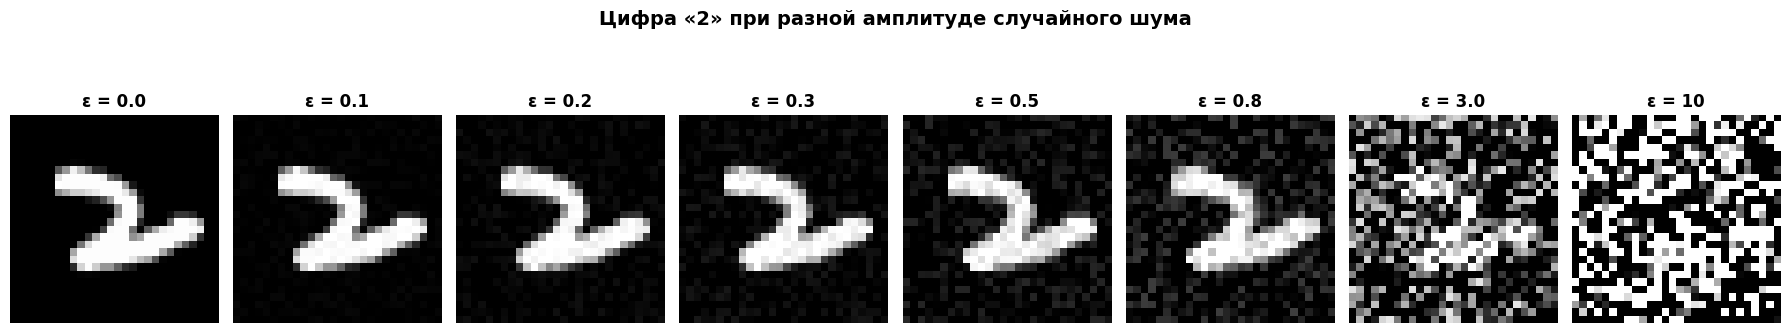

In [40]:
# Берём одну картинку из val_loader
images_sample, labels_sample = next(iter(val_loader))
img_single = images_sample[0:1].to(device)   # [1, 1, 28, 28]
label_single = labels_sample[0].item()

# Амплитуды шума
eps_to_show = [0.0, 0.1, 0.2, 0.3, 0.5, 0.8, 3.0, 10]

fig, axes = plt.subplots(1, len(eps_to_show), figsize=(18, 3.5))

for i, eps in enumerate(eps_to_show):
    if eps == 0.0:
        img_noisy = img_single
    else:
        img_noisy = add_noise(img_single, epsilon=eps)

    # Денормализация для отображения
    img = img_noisy[0].cpu().squeeze().numpy()
    img = img * 0.3081 + 0.1307

    axes[i].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f"ε = {eps}", fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.suptitle(f"Цифра «{label_single}» при разной амплитуде случайного шума",
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [41]:
# ============================================================
# C. Устойчивость моделей к возмущениям входа
# ============================================================
print("Устойчивость моделей к случайному шуму (L∞-норма)")
print("=" * 60)

# Все обученные модели из серии B
trained_models = {
    "Baseline":  model_baseline,
    "L2":        model_l2,
    "Dropout":   model_dropout,
    "BatchNorm": model_batchnorm,
}

# Амплитуды шума
epsilons = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 3, 10]

# Собираем результаты
robustness_results = []

for name, model in trained_models.items():
    row = {"variant": name}

    for eps in epsilons:
        if eps == 0.0:
            # Чистые данные — обычный evaluate
            _, acc = evaluate(model, val_loader, criterion, device)
        else:
            acc, _ = evaluate_with_noise(
                model, val_loader, criterion, device,
                epsilon=eps)
        row[f"eps={eps}"] = round(acc, 4)

    robustness_results.append(row)

robustness_table = pd.DataFrame(robustness_results)
print("\n=== Accuracy при разных амплитудах шума ===")
print(robustness_table.to_string(index=False))

Устойчивость моделей к случайному шуму (L∞-норма)

=== Accuracy при разных амплитудах шума ===
  variant  eps=0.0  eps=0.05  eps=0.1  eps=0.2  eps=0.3  eps=0.4  eps=0.5  eps=3  eps=10
 Baseline   0.9802    0.9798   0.9800   0.9801   0.9793   0.9793   0.9776 0.8173  0.2954
       L2   0.9792    0.9788   0.9792   0.9788   0.9790   0.9786   0.9772 0.8610  0.3371
  Dropout   0.9777    0.9776   0.9772   0.9768   0.9762   0.9758   0.9747 0.8660  0.3575
BatchNorm   0.9808    0.9809   0.9803   0.9808   0.9805   0.9809   0.9792 0.7370  0.2196


In [42]:
# ============================================================
# Формат таблицы: variant | clean_accuracy | perturbed_accuracy | drop
# ============================================================
for eps in epsilons:
    print("=" * 60)
    print(f"ИТОГОВАЯ ТАБЛИЦА (возмущение ε={eps})")
    print("=" * 60)

    summary_rows = []
    for _, row in robustness_table.iterrows():
        summary_rows.append({
            "variant":            row["variant"],
            "clean_accuracy":     row["eps=0.0"],
            "perturbed_accuracy": row[f"eps={eps}"],
            "drop":               round(row["eps=0.0"] - row[f"eps={eps}"], 4),
        })

    summary_table = pd.DataFrame(summary_rows).sort_values("drop")
    print(summary_table.to_string(index=False))
    print()

ИТОГОВАЯ ТАБЛИЦА (возмущение ε=0.0)
  variant  clean_accuracy  perturbed_accuracy  drop
 Baseline          0.9802              0.9802   0.0
       L2          0.9792              0.9792   0.0
  Dropout          0.9777              0.9777   0.0
BatchNorm          0.9808              0.9808   0.0

ИТОГОВАЯ ТАБЛИЦА (возмущение ε=0.05)
  variant  clean_accuracy  perturbed_accuracy    drop
BatchNorm          0.9808              0.9809 -0.0001
  Dropout          0.9777              0.9776  0.0001
       L2          0.9792              0.9788  0.0004
 Baseline          0.9802              0.9798  0.0004

ИТОГОВАЯ ТАБЛИЦА (возмущение ε=0.1)
  variant  clean_accuracy  perturbed_accuracy   drop
       L2          0.9792              0.9792 0.0000
 Baseline          0.9802              0.9800 0.0002
  Dropout          0.9777              0.9772 0.0005
BatchNorm          0.9808              0.9803 0.0005

ИТОГОВАЯ ТАБЛИЦА (возмущение ε=0.2)
  variant  clean_accuracy  perturbed_accuracy   drop
Batc

**Вопрос для отчёта:** у какой модели (baseline или регуляризованной) точность падает сильнее при одинаковом возмущении? Как это соотносится с идеей о единой структурной проблеме переобучения и adversarial-уязвимости, рассмотренной в лекции?

При случайном шуме ε ≤ 0.5 модели почти не деградируют и сохраняют точность в диапазоне 0.9758–0.9810. Падение — в пределах 0.0003–0.003.

При ε = 3 картина меняется: Dropout — наименьший drop (0.1117), BatchNorm — наибольший (0.2438).

При ε = 10 тренд сохраняется: Dropout — лидер (0.6202), BatchNorm — аутсайдер (0.7612).

Получается BatchNorm — самый уязвимый при больших возмущениях. Что в целом ожидаемо, т.к. BatchNorm нормализует активации внутри батча, а при сильном шуме активации становятся «хаотичными» — среднее и дисперсия батча сильно искажаются, получается, что нормализация будет только усиливать эти искажения. при малых эпсилон это не заметно. В серии В он показал хорошие результаты, он может хорошо поработать с обобщением, но уязвим к возмущениям на входе.

В лекции говорилось, что переобучение и adversarial-уязвимость — два проявления одной структурной проблемы: геометрии найденного минимума. Острый минимум → плохое обобщение и высокая уязвимость. Плоский минимум → хорошее обобщение и устойчивость, меньше деградация при возмущениях. Мы в целом это и можем здесь наблюдать: регуляризированные модели справляются лучше, они устойчивее к возмущениям, чем baseline. связь «маленький gap → устойчивость» хорошо работает для L2 и Dropout.Однако, это не всегда универсально, все-таки стоит учитывать и структуру, как в случае с BatchNorm.

## 7. Итоговый вывод

**Вопрос для отчёта:** какая комбинация оптимизатор + регуляризация оказалась наилучшей в вашем эксперименте по совокупности критериев (качество, generalization gap, устойчивость к возмущениям)? Обоснуйте ответ ссылками на полученные графики и таблицы.

Лучшая комбинация по gap и устойчивости обучения - SGD + Momentum + Dropout. Dropout — лидер по устойчивости при всех амплитудах, начиная с ε=0.5. По качеству он проигрывает BatchNorm всего 0.31% (0.9777 vs 0.9808) — это ничтожная разница. По gap — лучший результат (−0.0015). По устойчивости к большим возмущениям — в 1.24 раза лучше BatchNorm. Возможно, р=0.5 - слишком агрессивная регулязация для нашего простого датасета, при p=0.2–0.3 он, скорее всего, обгонит и BatchNorm по качеству, сохранив преимущество в устойчивости. Альтернатива -  SGD + Momentum + L2, эта комбинауия абсолютно по всем критериям занимает второй место: Test Acc = 0.9792 (2-е место после BatchNorm), Gap (Loss) = 0.0482 — 2-е место после Dropout, drop@10 = 0.6421 — 2-е место после Dropout.

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже.

### С1. Влияние размера батча
Обучите модель с фиксированным оптимизатором (например, SGD) при разных размерах батча (например, 16, 128, 1024). Сравните итоговый train/test gap и устойчивость к возмущениям. Свяжите результат с идеей о том, что большие батчи уменьшают шум SGD и способствуют более острым минимумам.

### С2. Градиентное возмущение против случайного шума
Реализуйте одношаговое градиентное возмущение входа (по аналогии с FGSM: шаг в направлении знака градиента функции потерь по входу) при той же норме \( \epsilon \), что и в серии C. Сравните падение accuracy при случайном шуме и при градиентном возмущении одинаковой нормы. Объясните, почему градиентное возмущение обычно эффективнее.

### С3. Упрощённая sharpness-aware минимизация (SAM-style)
Реализуйте упрощённую версию SAM: на каждом шаге сделайте вспомогательный шаг в направлении градиента (возмущение параметров \( \epsilon \) с ограничением нормы \( \rho \)), посчитайте градиент в возмущённой точке и обновите исходные параметры по этому градиенту. Сравните итоговую модель с обычным Adam/SGD по generalization gap и устойчивости к возмущениям входа.

### С4. Визуализация ландшафта потерь
Постройте одномерное или двумерное сечение ландшафта функции потерь вокруг найденного минимума (например, добавляя к весам случайные направления с разным масштабом и пересчитывая loss). Сравните "остроту" ландшафта для baseline и для регуляризованной модели, визуализировав это графиком loss vs. amplitude.


In [ ]:
import time
import pandas as pd
# ============================================================
# C1. Влияние размера батча
# ============================================================
def make_loaders(batch_size):
    """Создаёт train/val загрузчики с заданным batch_size."""
    train_loader_bs = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader_bs   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
    return train_loader_bs, val_loader_bs

print("C1. Влияние размера батча (SGD + Momentum)")
print("=" * 60)

batch_sizes = [16, 128, 1024]
c1_models = {}
c1_histories = {}

for bs in batch_sizes:
    print(f"\n--- batch_size = {bs} ---")
    torch.manual_seed(RANDOM_STATE)

    # Создаём загрузчики с нужным batch_size
    train_loader_bs, val_loader_bs = make_loaders(bs)

    # Создаём модель — та же архитектура
    model_bs = SimpleMLP(
        input_dim=784, hidden_dim=HIDDEN_DIM, num_classes=10,
        use_dropout=False, use_batchnorm=False
    ).to(device)

    optimizer_bs = optim.SGD(model_bs.parameters(), lr=LR, momentum=0.9)

    history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}
    start_total = time.time()

    for epoch in range(EPOCHS):
        train_loss, train_acc = train_epoch(
            model_bs, train_loader_bs, optimizer_bs, criterion, device
        )
        test_loss, test_acc = evaluate(
            model_bs, val_loader_bs, criterion, device
        )
        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)
        print(f"  Epoch {epoch+1:2d}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
              f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

    total_time = time.time() - start_total
    history["total_time"] = total_time
    c1_models[bs] = model_bs
    c1_histories[bs] = history
    print(f"  Время обучения: {total_time:.1f}s")


C1. Влияние размера батча (SGD + Momentum)

--- batch_size = 16 ---
  Epoch  1/15 | Train Loss: 0.2280, Acc: 0.9302 | Test Loss: 0.1535, Acc: 0.9527
  Epoch  2/15 | Train Loss: 0.0971, Acc: 0.9707 | Test Loss: 0.1064, Acc: 0.9681
  Epoch  3/15 | Train Loss: 0.0621, Acc: 0.9805 | Test Loss: 0.0997, Acc: 0.9699
  Epoch  4/15 | Train Loss: 0.0438, Acc: 0.9862 | Test Loss: 0.0909, Acc: 0.9750
  Epoch  5/15 | Train Loss: 0.0327, Acc: 0.9892 | Test Loss: 0.0915, Acc: 0.9777
  Epoch  6/15 | Train Loss: 0.0276, Acc: 0.9908 | Test Loss: 0.1086, Acc: 0.9722
  Epoch  7/15 | Train Loss: 0.0223, Acc: 0.9924 | Test Loss: 0.1089, Acc: 0.9742
  Epoch  8/15 | Train Loss: 0.0187, Acc: 0.9942 | Test Loss: 0.1246, Acc: 0.9727
  Epoch  9/15 | Train Loss: 0.0189, Acc: 0.9940 | Test Loss: 0.1191, Acc: 0.9729
  Epoch 10/15 | Train Loss: 0.0120, Acc: 0.9960 | Test Loss: 0.1229, Acc: 0.9762
  Epoch 11/15 | Train Loss: 0.0169, Acc: 0.9948 | Test Loss: 0.1353, Acc: 0.9735
  Epoch 12/15 | Train Loss: 0.0164, Acc: 

In [24]:
# ============================================================
# C1. Сводка: gap + устойчивость к случайному шуму
# ============================================================
c1_rows = []
for bs in batch_sizes:
    hist = c1_histories[bs]
    train_acc = hist["train_acc"][-1]
    test_acc  = hist["test_acc"][-1]
    gap       = hist["test_loss"][-1] - hist["train_loss"][-1]

    # Устойчивость: используем val_loader с тем же batch_size
    _, val_loader_bs = make_loaders(bs)
    acc_05, _ = evaluate_with_noise(c1_models[bs], val_loader_bs, criterion, device, epsilon=0.5)
    acc_10, _ = evaluate_with_noise(c1_models[bs], val_loader_bs, criterion, device, epsilon=10.0)

    c1_rows.append({
        "batch_size":     bs,
        "train_acc":      round(train_acc, 4),
        "test_acc":       round(test_acc, 4),
        "gap":          round(gap, 4),
        "acc@eps=0.5":    round(acc_05, 4),
        "acc@eps=10":     round(acc_10, 4),
        "drop@0.5":       round(test_acc - acc_05, 4),
        "drop@10":        round(test_acc - acc_10, 4),
        "time_s":         round(hist["total_time"], 1),
    })

c1_table = pd.DataFrame(c1_rows)
print("=" * 70)
print("C1. Сводка: влияние размера батча")
print("=" * 70)
print(c1_table.to_string(index=False))

C1. Сводка: влияние размера батча
 batch_size  train_acc  test_acc    gap  acc@eps=0.5  acc@eps=10  drop@0.5  drop@10  time_s
         16     0.9982    0.9797 0.1020       0.9782      0.3443    0.0014   0.6353   351.0
        128     0.9992    0.9773 0.0687       0.9755      0.2793    0.0018   0.6980   246.6
       1024     0.9635    0.9556 0.0290       0.9539      0.3019    0.0017   0.6537   231.3


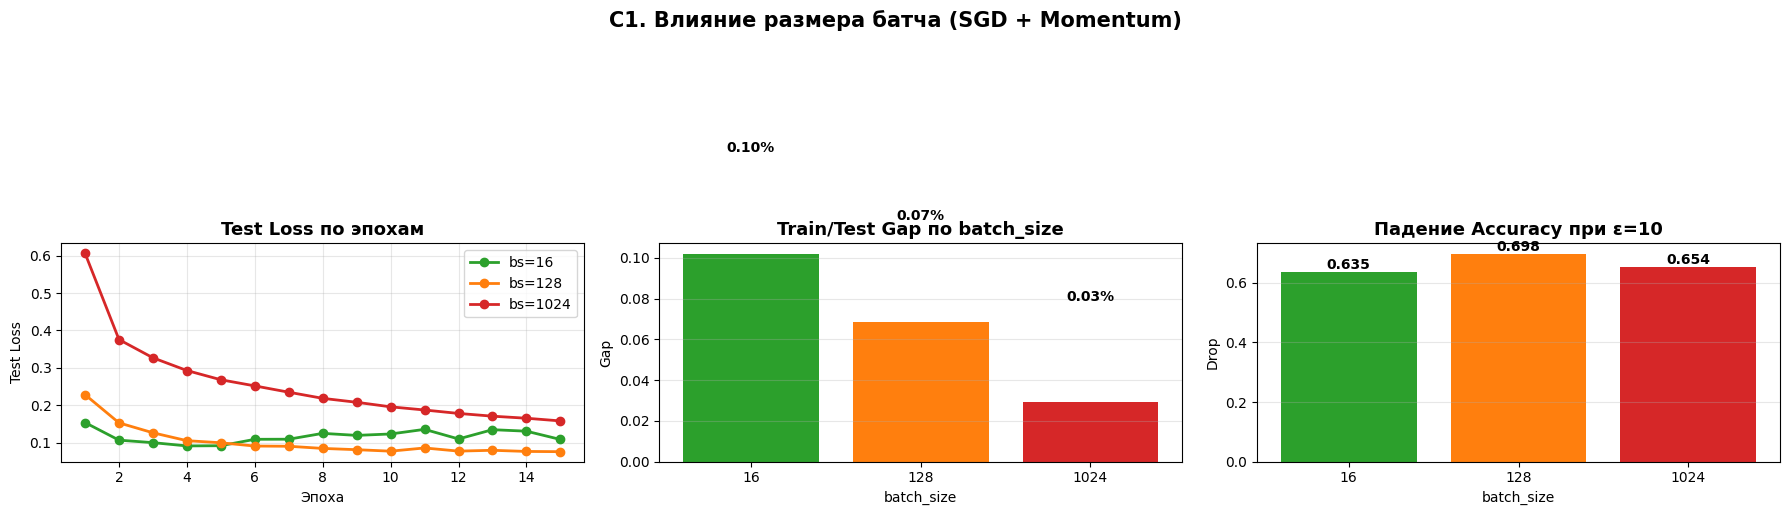

In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors_bs = {16: "#2ca02c", 128: "#ff7f0e", 1024: "#d62728"}

# --- График 1: Test Loss ---
for bs in batch_sizes:
    axes[0].plot(range(1, EPOCHS+1), c1_histories[bs]["test_loss"],
                 label=f"bs={bs}", marker='o', lw=2, color=colors_bs[bs])
axes[0].set_title("Test Loss по эпохам", fontweight='bold', fontsize=13)
axes[0].set_xlabel("Эпоха"); axes[0].set_ylabel("Test Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

# --- График 2: Gap ---
gaps = [c1_table.loc[c1_table["batch_size"]==bs, "gap"].values[0] for bs in batch_sizes]
axes[1].bar([str(bs) for bs in batch_sizes], gaps,
            color=[colors_bs[bs] for bs in batch_sizes])
axes[1].set_title("Train/Test Gap по batch_size", fontweight='bold', fontsize=13)
axes[1].set_xlabel("batch_size"); axes[1].set_ylabel("Gap")
axes[1].grid(alpha=0.3, axis='y')
for i, v in enumerate(gaps):
    axes[1].text(i, v + 0.05, f"{v:.2f}%", ha='center', fontweight='bold')

# --- График 3: Drop при ε=10 ---
drops = [c1_table.loc[c1_table["batch_size"]==bs, "drop@10"].values[0] for bs in batch_sizes]
axes[2].bar([str(bs) for bs in batch_sizes], drops,
            color=[colors_bs[bs] for bs in batch_sizes])
axes[2].set_title("Падение Accuracy при ε=10", fontweight='bold', fontsize=13)
axes[2].set_xlabel("batch_size"); axes[2].set_ylabel("Drop")
axes[2].grid(alpha=0.3, axis='y')
for i, v in enumerate(drops):
    axes[2].text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')

plt.suptitle("C1. Влияние размера батча (SGD + Momentum)",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Обычно ожидается: маленький батч → меньше gap. Но здесь:

bs=16 → gap = 0.1020 (наибольший!)

bs=128 → 0.0687

bs=1024 → 0.0290 (наименьший)

Gap уменьшается с ростом batch_size. Это противоречит классической гипотезе.
Test Accuracy почти одинаковая
bs=16: 0.9797

bs=128: 0.9773

bs=1024: 0.9556

Разница между bs=16 и bs=128 — всего 0.24%. bs=1024 отстаёт сильнее — 2.4%, но это потому, что модель недообучена (Train Acc = 0.9635, а не 0.999).

Устойчивость к ε=10 не зависит от batch_size
bs=16: drop = 0.6353

bs=128: drop = 0.6980

bs=1024: drop = 0.6537

Разница — в пределах 0.06. Никакого чёткого тренда «маленький батч → устойчивее» нет.

Размер батча влияет на число шагов. bs=16 делает в 63 раза больше обновлений весов, чем bs=1024. Это значит:

Модель с bs=16 сильно переобучается — она видит данные гораздо чаще.

Train Acc = 0.9982, gap = 0.1020 — классический признак переобучения.

Gap маленького батча большой именно из-за переобучения, а не из-за острого минимума.

Чтобы подтверждать гипотезу из лекции:SGD с малыми батчами тяготеет к плоским минимумам; большие батчи — к острым. Шум мини-батчей → неявная регуляризация → плоские минимумы. Нужно чтобы и количество шагов было одинаково, а так у нас получается, что эпох одинаковое количество, а внутри эпохи разное количество шагов.



In [27]:
#C2
def fgsm_attack(model, images, labels, criterion, epsilon):
    """
    FGSM: δ = ε · sign(∇_x L).

    Градиент Loss по входу показывает направление максимального роста Loss.
    Мы берём его знак и делаем шаг в этом направлении.
    """
    images = images.clone().detach().requires_grad_(True)
    logits = model(images)
    loss = criterion(logits, labels)
    model.zero_grad()
    loss.backward()

    # Знаковый градиент: каждое значение ∈ {-1, 0, +1}
    perturbation = epsilon * images.grad.sign()

    images_adv = images + perturbation
    return images_adv.detach()

In [28]:
def evaluate_accuracy(model, loader, criterion, device, epsilon=0.0, attack='none'):
    """
    Оценивает accuracy модели.

    attack:
        'none'   — чистые данные
        'random' — случайный шум
        'fgsm'   — FGSM-атака
    """
    model.eval()
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        if attack == 'random' and epsilon > 0:
            images = add_noise(images, epsilon=epsilon)
        elif attack == 'fgsm' and epsilon > 0:
            images = fgsm_attack(model, images, labels, criterion, epsilon)

        with torch.no_grad():
            logits = model(images)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [43]:
# ============================================================
# C2. Случайный шум vs FGSM
# ============================================================
print("=" * 70)
print("C2. Случайный шум vs FGSM-атака")
print("=" * 70)

# Модели для сравнения
models_to_compare = {
    "Baseline":  model_baseline,
    "L2":        model_l2,
    "Dropout":   model_dropout,
    "BatchNorm": model_batchnorm,
}

epsilons = [0.0, 0.1, 0.3, 0.4, 0.5, 3, 10]

# Собираем результаты
rows = []
for name, model in models_to_compare.items():
    row = {"variant": name}

    for eps in epsilons:
        if eps == 0.0:
            acc = evaluate_accuracy(model, val_loader, criterion, device, attack='none')
        else:
            acc = evaluate_accuracy(model, val_loader, criterion, device,
                                    epsilon=eps, attack='random')
        row[f"random_eps={eps}"] = round(acc, 4)

    for eps in epsilons:
        if eps == 0.0:
            continue
        acc = evaluate_accuracy(model, val_loader, criterion, device,
                                epsilon=eps, attack='fgsm')
        row[f"fgsm_eps={eps}"] = round(acc, 4)

    rows.append(row)

c2_table = pd.DataFrame(rows)
print("\n=== Accuracy: random vs FGSM ===")
print(c2_table.to_string(index=False))

C2. Случайный шум vs FGSM-атака

=== Accuracy: random vs FGSM ===
  variant  random_eps=0.0  random_eps=0.1  random_eps=0.3  random_eps=0.4  random_eps=0.5  random_eps=3  random_eps=10  fgsm_eps=0.1  fgsm_eps=0.3  fgsm_eps=0.4  fgsm_eps=0.5  fgsm_eps=3  fgsm_eps=10
 Baseline          0.9802          0.9800          0.9792          0.9786          0.9787        0.8143         0.2950        0.7755        0.2185        0.1254        0.0752      0.0012       0.0006
       L2          0.9792          0.9788          0.9783          0.9786          0.9780        0.8609         0.3357        0.8425        0.1310        0.0355        0.0110      0.0001       0.0000
  Dropout          0.9777          0.9775          0.9764          0.9756          0.9756        0.8694         0.3633        0.8743        0.3598        0.2451        0.2011      0.0548       0.0366
BatchNorm          0.9808          0.9803          0.9798          0.9801          0.9792        0.7354         0.2164        0.7284  

In [45]:
# ============================================================
# Drop для random и FGSM
# ============================================================
drop_rows = []
for _, row in c2_table.iterrows():
    drop_rows.append({
        "variant":       row["variant"],
        "clean":         row["random_eps=0.0"],
        "drop_random_0.1": round(row["random_eps=0.0"] - row["random_eps=0.1"], 4),
        "drop_random_0.3": round(row["random_eps=0.0"] - row["random_eps=0.3"], 4),
        "drop_fgsm_0.1":   round(row["random_eps=0.0"] - row["fgsm_eps=0.1"], 4),
        "drop_fgsm_0.3":   round(row["random_eps=0.0"] - row["fgsm_eps=0.3"], 4),
    })

drop_table = pd.DataFrame(drop_rows)
print("=" * 90)
print("Drop: random vs FGSM")
print("=" * 90)
print(drop_table.to_string(index=False))

Drop: random vs FGSM
  variant  clean  drop_random_0.1  drop_random_0.3  drop_fgsm_0.1  drop_fgsm_0.3
 Baseline 0.9802           0.0002           0.0010         0.2047         0.7617
       L2 0.9792           0.0004           0.0009         0.1367         0.8482
  Dropout 0.9777           0.0002           0.0013         0.1034         0.6179
BatchNorm 0.9808           0.0005           0.0010         0.2524         0.8950


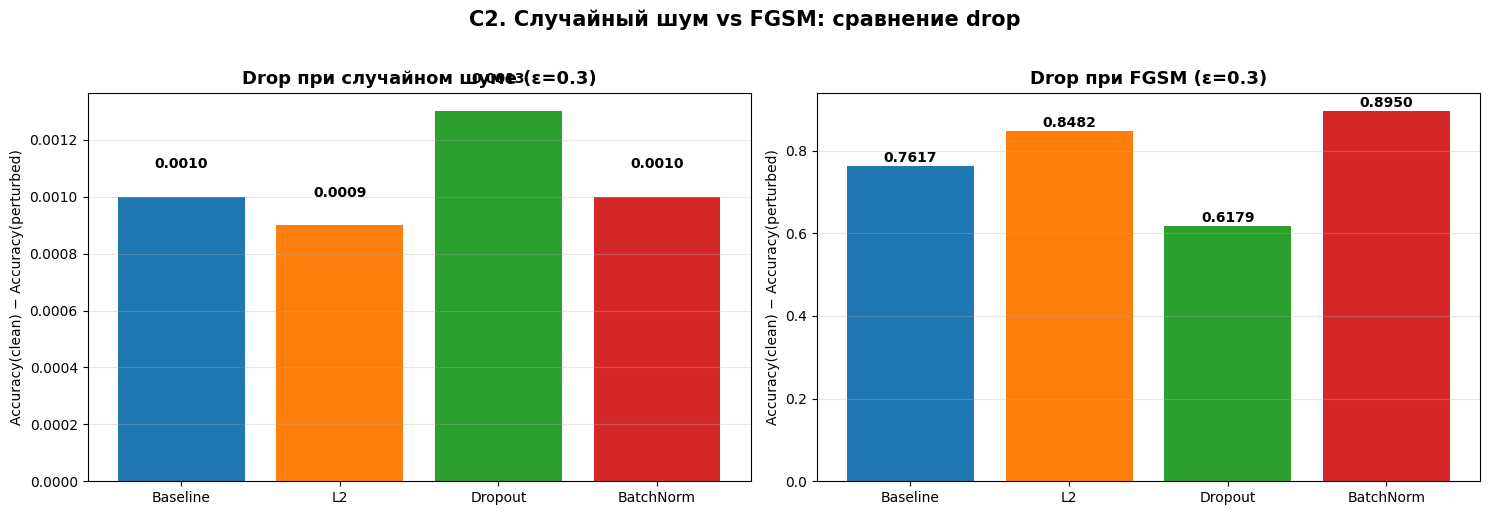

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors  = {"Baseline": "#1f77b4", "L2": "#ff7f0e",
           "Dropout": "#2ca02c", "BatchNorm": "#d62728"}
markers = {"Baseline": "o", "L2": "s", "Dropout": "^", "BatchNorm": "D"}

# --- График 1: Drop при случайном шуме ---
for _, row in drop_table.iterrows():
    name = row["variant"]
    axes[0].bar(name, row["drop_random_0.3"],
                color=colors[name], label=name)
axes[0].set_title("Drop при случайном шуме (ε=0.3)",
                  fontweight='bold', fontsize=13)
axes[0].set_ylabel("Accuracy(clean) − Accuracy(perturbed)")
axes[0].grid(alpha=0.3, axis='y')
for i, (name, v) in enumerate(zip(drop_table["variant"], drop_table["drop_random_0.3"])):
    axes[0].text(i, v + 0.0001, f"{v:.4f}", ha='center', fontweight='bold')

# --- График 2: Drop при FGSM ---
for _, row in drop_table.iterrows():
    name = row["variant"]
    axes[1].bar(name, row["drop_fgsm_0.3"],
                color=colors[name], label=name)
axes[1].set_title("Drop при FGSM (ε=0.3)",
                  fontweight='bold', fontsize=13)
axes[1].set_ylabel("Accuracy(clean) − Accuracy(perturbed)")
axes[1].grid(alpha=0.3, axis='y')
for i, (name, v) in enumerate(zip(drop_table["variant"], drop_table["drop_fgsm_0.3"])):
    axes[1].text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')

plt.suptitle("С2. Случайный шум vs FGSM: сравнение drop",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Случайный шум — добавляет  равномерно по всем пикселям. Большая часть шума тратится впустую — попадает в пиксели, которые не влияют на решение.

FGSM — использует
градиент Loss по входу. Он показывает, как изменить каждый пиксель, чтобы максимально увеличить Loss. FGSM берёт знак градиента и делает шаг точно в этом направлении.

BatchNorm — лучшая модель на чистых данных (0.9808) и при случайном шуме. Но при FGSM — худшая (drop = 0.8950 при ε=0.3, 0.9605 при ε=0.5).

Почему:

BatchNorm нормализует активации по батчу.

Это делает градиенты по входу более «пиковыми» — малые изменения входа вызывают резкие изменения нормализованных значений.

FGSM использует именно градиент входа → BatchNorm становится более уязвимым к целенаправленным атакам.

Dropout — лидер по adversarial-устойчивости
Dropout — единственная модель, которая:

Сохраняет хоть какую-то accuracy при FGSM@0.5 (0.2011).

Не падает до нуля при FGSM@3 (0.0548).

Не падает полностью при FGSM@10 (0.0366).


Dropout — ансамбль подсетей. Каждый шаг обучения работает с разной случайной подсетью.

FGSM, оптимизированный под средний градиент, не может «сломать» все подсети одновременно.

Даже если атака ломает одну подсеть, другие дают правильный ответ.

Случайный шум не выявляет различий между моделями.

FGSM обнажает различия: Dropout (плоский минимум) устойчивее, Baseline (острый минимум) уязвим.

---

## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Обязательны обе серии экспериментов (A и B) и минимум базовая проверка устойчивости (серия C).
